Agentic RAG with LangGraph
=====

In [1]:
import os
from pathlib import Path
from typing import Annotated, TypedDict, Sequence
from dotenv import load_dotenv
from IPython.display import display

from langchain_groq import ChatGroq
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages

/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_75044/1890388311.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


## A recap of LLM setup and tool calling

In [2]:
project_root = Path().cwd().parent

load_dotenv(project_root / ".env")

assert os.getenv("GROQ_API_KEY"), "Please put API KEY in '.env'"


@tool
def get_weather(city: str) -> str:
    """A tool that returns the weather in a city"""
    if city == "San Francisco":
        return f"It's 67F and sunny in {city}"
    else:
        return f"It's 92F and humid in {city}"

tools = [get_weather]

tools_dict = {t.name: t for t in tools}
print(tools_dict)

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden"
).bind_tools([get_weather])

print(llm.invoke("Hi, how are you?").content)
response = llm.invoke("How is the weather in San Francisco?")
if hasattr(response, "tool_calls") and response.tool_calls:
    print(f"\n  🛠️ USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    for t in response.tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided!')}")
        result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
        print(f"ToolCall result: {result}")

{'get_weather': StructuredTool(name='get_weather', description='A tool that returns the weather in a city', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x105a1b560>)}
I'm an AI assistant, so I don't have feelings, but I'm here to help! How can I assist you today? 😊

  🛠️ USING TOOLS: ['get_weather']
Calling Tool: get_weather with query: No query provided!
ToolCall result: It's 92F and humid in 


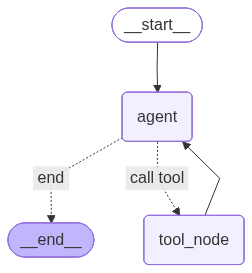

In [19]:
class RecapExampleState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def call_llm(state: RecapExampleState) -> RecapExampleState:
    #print("****call_llm>>>", state["messages"])
    system_prompt = SystemMessage(
        content="You are a helpful assistant. Please answer the question to the best of your ability."
    )
    response = llm.invoke([system_prompt] + state["messages"])
    print("call_llm>>", response)
    return {"messages": [response]}


def decide_next_action(state: RecapExampleState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "call tool"
    else:
        return "end"
    
builder = StateGraph(RecapExampleState)
builder.add_node("agent", call_llm)
tool_node = ToolNode(tools=tools)  # this node handles tool-callings
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    decide_next_action, # action function
    {
        "call tool": "tool_node",
        "end": END
    }
)
builder.add_edge("tool_node", "agent")

graph = builder.compile()
display(graph)

In [18]:
graph.invoke({"messages": ["How is the weather todat in San Francisco?"]})

call_llm>> content='' additional_kwargs={'tool_calls': [{'id': 'bxm3a77vz', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 176, 'total_tokens': 292, 'completion_time': 0.17892872, 'completion_tokens_details': {'reasoning_tokens': 92}, 'prompt_time': 0.007161569, 'prompt_tokens_details': None, 'queue_time': 0.021554568, 'total_time': 0.186090289}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f1107-eb62-73f2-8db2-b68615382dfe-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'bxm3a77vz', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 176, 'output_tokens': 116, 'total_tokens': 292, 'output_token_details': {'reasoning': 92}}
call_llm>> content='The weather in S

{'messages': [HumanMessage(content='How is the weather todat in San Francisco?', additional_kwargs={}, response_metadata={}, id='b2aed292-94ef-4838-a7f5-114cd264bce1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bxm3a77vz', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 176, 'total_tokens': 292, 'completion_time': 0.17892872, 'completion_tokens_details': {'reasoning_tokens': 92}, 'prompt_time': 0.007161569, 'prompt_tokens_details': None, 'queue_time': 0.021554568, 'total_time': 0.186090289}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1107-eb62-73f2-8db2-b68615382dfe-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'bxm3a77vz', 'type': 'tool_call'}], invali

In [20]:
graph.invoke({"messages": ["Is it warmer in San Francisco or Miami?"]})

call_llm>> content='' additional_kwargs={'tool_calls': [{'id': '08551whj0', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'h7z6qt2fh', 'function': {'arguments': '{"city":"Miami"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 222, 'prompt_tokens': 175, 'total_tokens': 397, 'completion_time': 0.444894071, 'completion_tokens_details': {'reasoning_tokens': 178}, 'prompt_time': 0.006991791, 'prompt_tokens_details': None, 'queue_time': 0.022929656, 'total_time': 0.451885862}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f1108-858e-74e2-b882-49c707db7764-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': '08551whj0', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'Miami'}, 'id': 'h7z6qt2fh'

{'messages': [HumanMessage(content='Is it warmer in San Francisco or Miami?', additional_kwargs={}, response_metadata={}, id='5861560e-a8e8-4237-ae42-8a74f5ab6177'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '08551whj0', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'h7z6qt2fh', 'function': {'arguments': '{"city":"Miami"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 222, 'prompt_tokens': 175, 'total_tokens': 397, 'completion_time': 0.444894071, 'completion_tokens_details': {'reasoning_tokens': 178}, 'prompt_time': 0.006991791, 'prompt_tokens_details': None, 'queue_time': 0.022929656, 'total_time': 0.451885862}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1108-858e-74e2-b882-49c707db7764-0', tool_call

### Replacing with langchain agents

In [14]:
from langchain.agents import create_agent

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=tools,
    system_prompt="You are a helpful assistant."
)

agent.invoke({"messages": ["Is it warmer in San Francisco or Miami?"]})

{'messages': [HumanMessage(content='Is it warmer in San Francisco or Miami?', additional_kwargs={}, response_metadata={}, id='c8df65b3-3de7-4b1f-87b3-99ee76618992'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking whether it\'s warmer in San Francisco or Miami. I need to figure out the current weather in both cities to compare. The tool provided is get_weather, which requires the city name. So I should call this function for both San Francisco and Miami. Let me make sure to structure the tool calls correctly. First, get the weather for San Francisco, then for Miami. Once I have both temperatures, I can compare them and give the answer. Let me check the parameters again: the function needs "city" as a string. No typos in the city names. Alright, time to make the tool calls.\n', 'tool_calls': [{'id': '8nmdb09wn', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'd3ppnn4ky', 'function': {'ar

## Agentic RAG

In [2]:
project_root = Path().cwd().parent

load_dotenv(project_root / ".env")

assert os.getenv("GROQ_API_KEY"), "Please put API KEY in '.env'"


In [12]:
import logging
logging.getLogger("pypdf").setLevel(logging.ERROR)

pdf_paths = list((project_root / "data" / "raw" / "chapters").glob("*.pdf"))
#pdf_paths = list((project_root / "data" / "raw" / "arxiv").glob("*.pdf"))

documents = []
for pdf_path in pdf_paths:
    loader = PyPDFLoader(pdf_path)
    documents.extend(loader.load())

In [13]:
# splitting texts

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False
)

chunks = text_splitter.split_documents(documents)

print(f"Split documents into {len(chunks)} chunks")

Split documents into 391 chunks


In [14]:
embedding = OpenAIEmbeddings(
    model="text-embedding-3-large",
)

vector_store = Chroma.from_documents(
        chunks,
        embedding=embedding,
        #persist_directory=project_root / "data" / "rag_data" / "chapters",
    )

# testing the similarity search
vector_store.similarity_search_with_score(
    "What is the purpose of padding in convolution?",
    k=3
)


[(Document(id='06cb36da-db58-4eb7-9846-fd99c41a9bb2', metadata={'page': 5, 'page_label': '6', 'title': 'B36694_14-v2', 'creator': 'Word', 'producer': 'macOS Version 26.6 (Build 25G5043d) Quartz PDFContext', 'moddate': "D:20260629014538Z00'00'", 'total_pages': 47, 'creationdate': "D:20260629014538Z00'00'", 'source': '/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/data/raw/chapters/ch14_convolution.pdf', 'author': 'VM'}, page_content='stride 2 instead. This designed principle was discussed in Striving for Simplicity: The All Convolutional Net ICLR (workshop track), by Jost Tobias Springenberg, Alexey Dosovitskiy, and others, 2015 (https://arxiv.org/abs/1412.6806). As for full padding, it produces an output that is larger than the input. Full padding is commonly used in signal processing applications where it is important to minimize boundary effects. However, in deep learning applications, boundary effects are usually not a major concern, so full padding is rarely used in pra

In [15]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},
)

@tool
def retrieve_information(query: str):
    """
    A tool to retrieve relevant information from the knowldge base for a given query
    """
    results = retriever.invoke(query)
    return results


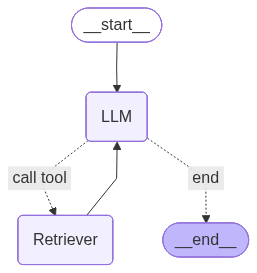

In [16]:

class RAGState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden"
).bind_tools([retrieve_information])

def call_llm(state: RAGState) -> RAGState:
    system_prompt = SystemMessage("""
You are a helpful assistant. To answer user's questions about convolution / transformers / diffusion,
look up relevent information from the knowledge base.
""")
    response = llm.invoke([system_prompt] + state["messages"])
    return {
        "messages": response
    }


def decide_next_action(state: RAGState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "call tool"
    else:
        return "end"

builder = StateGraph(RAGState)
builder.add_node("LLM", call_llm)
tool_node = ToolNode(tools=[retrieve_information])
builder.add_node("Retriever", tool_node)
builder.add_edge(START, "LLM")
builder.add_conditional_edges(
    "LLM",
    decide_next_action,
    {"call tool": "Retriever", "end": END}
)
builder.add_edge("Retriever", "LLM")
graph = builder.compile()

display(graph)

In [17]:
graph.invoke({
    "messages": ["What is the purpose of pooling in CNNs?"]
})

{'messages': [HumanMessage(content='What is the purpose of pooling in CNNs?', additional_kwargs={}, response_metadata={}, id='35ef9930-b4f5-46c7-9ef0-7543d14abccc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'hpbmdge84', 'function': {'arguments': '{"query":"purpose of pooling in CNNs"}', 'name': 'retrieve_information'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 221, 'prompt_tokens': 194, 'total_tokens': 415, 'completion_time': 0.394028491, 'completion_tokens_details': {'reasoning_tokens': 193}, 'prompt_time': 0.018138428, 'prompt_tokens_details': None, 'queue_time': 0.179538686, 'total_time': 0.412166919}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1159-4cc2-7371-840f-82b7f45543ea-0', tool_calls=[{'name': 'retrieve_information', 'args': {'query': 'purpose of pooling in CNNs'}, 'id